## Importing Libraries

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import re
from sklearn.preprocessing import LabelEncoder
from bs4 import BeautifulSoup
from sklearn.feature_extraction.text import TfidfVectorizer
from hazm import stopwords_list
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score)
from scipy.sparse import hstack, csr_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, classification_report
from sklearn.metrics import f1_score, classification_report

In [2]:
# Loading Data ...
df = pd.read_csv("digikala-comments.csv",low_memory=False)

## EDA

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6156289 entries, 0 to 6156288
Data columns (total 15 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   id                     int64  
 1   title                  object 
 2   body                   object 
 3   created_at             object 
 4   rate                   float64
 5   recommendation_status  object 
 6   is_buyer               bool   
 7   product_id             int64  
 8   advantages             object 
 9   disadvantages          object 
 10  likes                  int64  
 11  dislikes               int64  
 12  seller_title           object 
 13  seller_code            object 
 14  true_to_size_rate      object 
dtypes: bool(1), float64(1), int64(4), object(9)
memory usage: 663.4+ MB
None


true_to_size_rate        98.525524
disadvantages            93.303238
advantages               88.496235
title                    46.538783
recommendation_status    14.528655
seller_title              4.908493
seller_code               4.908493
body                      0.010347
rate                      0.000000
created_at                0.000000
id                        0.000000
is_buyer                  0.000000
product_id                0.000000
likes                     0.000000
dislikes                  0.000000
dtype: float64


                 id          rate    product_id         likes      dislikes
count  6.156289e+06  6.156289e+06  6.156289e+06  6.156289e+06  6.156289e+06
mean   3.704709e+07  3.648286e+00  3.908983e+06  4.503171e-01  8.687068e-02
std    1.393243e+07  1.861854e+00  3.015881e+06  2.294114e+00  8.313516e-01
min    9.815860e+05  0.000000e+00  7.602000e+03  0.000000e+00  0.000000e+00
25%    2.731234e+07  3.000000e+00  1.532375e+06  0.000000e+00  0.000000e+00
50%    4.044773e+07  4.000000e+00  3.183184e+06  0.000000e+00  0.000000e+00
75%    4.897122e+07  5.000000e+00  5.992988e+06  0.000000e+00  0.000000e+00
max    5.474516e+07  2.500000e+03  1.270221e+07  1.136000e+03  3.360000e+02
(6156289, 15)


1318


<Axes: >

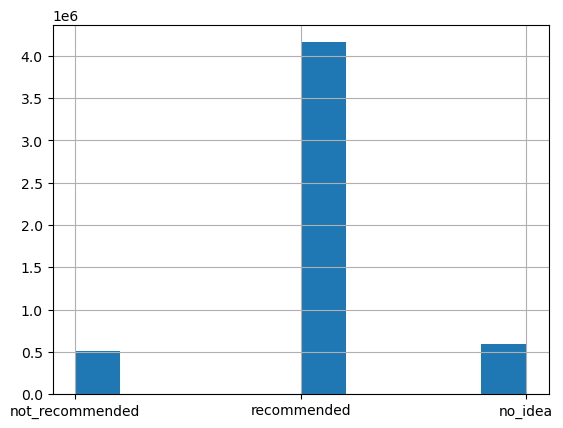

In [3]:
print("="*70)
print(df.info())
print("="*70)
print(df.isna().mean().mul(100).sort_values(ascending=False))
print("="*70)
print(df.describe())
print("="*70)
print(df.shape)
print("="*70)
print(df.duplicated().sum())
print("="*70)
df["recommendation_status"].hist()

## Preprocessing

In [3]:
df.drop(labels=["id","created_at","product_id","true_to_size_rate","disadvantages","advantages","seller_title","seller_code"],axis=1,inplace=True)
df["sentence"] = df["title"] + " " + df["body"]
df.drop(labels=["title","body"],axis=1,inplace=True)
df.drop_duplicates(inplace=True)
df.dropna(inplace=True)
df["sentence"] = df["sentence"].astype(str)
df["sentence"] = df["sentence"].apply(
    lambda x: BeautifulSoup(x, "html.parser").get_text())
df["sentence"] = df["sentence"].str.lower()
df["sentence"] = df["sentence"].apply(
    lambda x: re.sub(r"http\S+|www\S+", "", x))
df["sentence"] = df["sentence"].apply(
    lambda x: re.sub(r"[^\w\s]", "", x))
df["sentence"] = df["sentence"].apply(
    lambda x: re.sub(r"\d+", " ", x))
stop_words = set(stopwords_list())
df["sentence"] = df["sentence"].apply(
    lambda x: " ".join(
        word for word in x.split()
        if word not in stop_words))
df = df[df["sentence"].str.strip() != ""]

In [5]:
print(df.info())
print("======================================")
print(df.isna().sum())
print("======================================")
df

<class 'pandas.core.frame.DataFrame'>
Index: 2598641 entries, 0 to 6156288
Data columns (total 6 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   rate                   float64
 1   recommendation_status  object 
 2   is_buyer               bool   
 3   likes                  int64  
 4   dislikes               int64  
 5   sentence               object 
dtypes: bool(1), float64(1), int64(2), object(2)
memory usage: 121.4+ MB
None


rate                     0
recommendation_status    0
is_buyer                 0
likes                    0
dislikes                 0
sentence                 0
dtype: int64


,rate,recommendation_status,is_buyer,likes,dislikes,sentence
0,1.0,not_recommended,True,0,0,پیشنهاد نمیشود درد نمیخوره
1,0.0,recommended,True,1,0,بسته بد میتونست عنوان یه کالای فرهنگی بسته بشه
2,0.0,recommended,True,0,0,برس ریمل بسته بندیش کاربرد کیفیتشم خوبه روغن ز...
3,0.0,recommended,True,0,0,خوبه خوشرنگ نظرم خوبه یکم ظریفه رنگش خوشم اومد...
4,3.0,recommended,True,0,0,برس رنگ مو معمولیه اگه واسه خونه رنگ میخواین ا...
...,...,...,...,...,...,...
6156271,1.0,not_recommended,True,4,2,دستگاه های کپی اصل ارسال سلام دستگاهی های کپی ...
6156276,4.0,recommended,True,0,0,شارزر سیم ps خوبه کار اندازه
6156277,1.0,not_recommended,True,4,0,کالا عکس توضیحات مطابقت اصل میباشد کالا عکس تو...
6156281,4.0,recommended,True,2,0,اصلی میاد نمیدونم هیچوقت هیچی ایران ارزون نمیش...


## Processing

In [5]:
X = df.drop(["recommendation_status"],axis=1)
y = df["recommendation_status"]
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

## Modeling(TF_IDF + LinearSVC)

In [7]:
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_features=100000)
X_text_train = tfidf.fit_transform(X_train["sentence"])
X_text_test = tfidf.transform(X_test["sentence"])
numeric_cols = ["rate", "likes", "dislikes", "is_buyer"]
scaler = StandardScaler()
X_numeric_train = scaler.fit_transform(
    X_train[numeric_cols].astype(float))
X_numeric_test = scaler.transform(
    X_test[numeric_cols].astype(float))
X_train_final = hstack([
    X_text_train,
    csr_matrix(X_numeric_train)])
X_test_final = hstack([
    X_text_test,
    csr_matrix(X_numeric_test)])
model = LinearSVC(
    C=1.0,
    class_weight="balanced")
model.fit(X_train_final, y_train)
y_pred = model.predict(X_test_final)
print("Macro F1:", f1_score(
    y_test,
    y_pred,
    average="macro"))
print(classification_report(
    y_test,
    y_pred,
    digits=4))

Macro F1: 0.6943043462068877


                 precision    recall  f1-score   support

        no_idea     0.4179    0.4211    0.4195     55559
not_recommended     0.7023    0.7835    0.7407     62443
    recommended     0.9316    0.9139    0.9227    401727

       accuracy                         0.8456    519729
      macro avg     0.6840    0.7062    0.6943    519729
   weighted avg     0.8492    0.8456    0.8470    519729



## Simple Tuning

In [9]:
for C in [0.1 , 0.3 , 0.5, 1.5, 3.0]:
    model = LinearSVC(
        C=C,
        class_weight="balanced")
    model.fit(X_train_final, y_train)
    y_pred = model.predict(X_test_final)
    f1 = f1_score(
        y_test,
        y_pred,
        average="macro")
    print(f"C = {C}  -->  Macro F1 = {f1:.4f}")

C = 0.1  -->  Macro F1 = 0.7040


C = 0.3  -->  Macro F1 = 0.6999


C = 0.5  -->  Macro F1 = 0.6974


C = 1.5  -->  Macro F1 = 0.6925


C = 3.0  -->  Macro F1 = 0.6897


# Best (TF_IDF + LinearSVC) F1 Score = 0.7040